<a href="https://colab.research.google.com/github/ashia-002/machine-learning-with-pandas-numpy/blob/main/Model_Implementation/Clustering/K_means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
import pandas as pd
import numpy as np


df = pd.read_csv("/content/players_22.csv")

/tmp/ipython-input-3667761796.py:5: DtypeWarning: Columns (25,108) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/players_22.csv")


In [56]:
df.head(5)

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png


From this data we will only be clustering **player_positions 	overall 	potential 	value_eur 	wage_eur 	age**.

In [57]:
features = ['overall', 'potential', 'value_eur', 'wage_eur', 'age']

In [58]:
# For these features we are droping any missing value rows
players = df.dropna(subset=features)

In [82]:
#Copying into new dataframe
data = players[features].copy()

In [83]:
data

,overall,potential,value_eur,wage_eur,age
0,93,93,78000000.0,320000.0,34
1,92,92,119500000.0,270000.0,32
2,91,91,45000000.0,270000.0,36
3,91,91,129000000.0,270000.0,29
4,91,91,125500000.0,350000.0,30
...,...,...,...,...,...
19234,47,52,70000.0,1000.0,22
19235,47,59,110000.0,500.0,19
19236,47,55,100000.0,500.0,21
19237,47,60,110000.0,500.0,19


## Manual Scalling

In [84]:
X = data.values

# compute mean ans std
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

# avoid division by zero
std[std==0] = 1

data_scaled = (X - mean) / std

# K-Means from Scratch
### Step 1: Initialize centroids
Randomly pick k points from the data.


In [87]:
def initialize_centroids(X, k):
    indices = np.random.choice(len(X), k, replace=False)
    return X[indices]


### Step 2: Assign clusters
Euclidean distance

In [88]:
def assign_clusters(X, centroids):
    clusters = np.zeros(len(X), dtype=int)
    for i, x in enumerate(X):
        distances = np.linalg.norm(x - centroids, axis=1)
        clusters[i] = np.argmin(distances)
    return clusters


### Update centroids
Mean of all points in a cluster.

In [89]:
def update_centroids(X, clusters, k):
    centroids = np.zeros((k, X.shape[1]))
    for i in range(k):
        points = X[clusters == i]
        if len(points) > 0:
            centroids[i] = points.mean(axis=0)
    return centroids


### Step 4: Full K-Means algorithm

In [90]:
def kmeans(X, k, max_iters=100):
    centroids = initialize_centroids(X, k)

    for _ in range(max_iters):
        clusters = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, clusters, k)

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return clusters, centroids


In [112]:
k = 3

clusters, centroids = kmeans(data_scaled, k)

players['cluster'] = clusters
players.groupby('cluster')[features].mean()


/tmp/ipython-input-3667704764.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  players['cluster'] = clusters


,overall,potential,value_eur,wage_eur,age
cluster,,,,,
0,80.323360,83.165708,2.914960e+07,72143.843498,26.280783
1,60.862991,70.638363,9.315516e+05,2443.115697,21.397609
2,69.024183,70.381417,2.231323e+06,9391.466907,28.656661


In [113]:
def pca_from_scratch(X, n_components=2):
    # Center the data
    X_centered = X - np.mean(X, axis=0)

    # Covariance matrix
    cov_matrix = np.cov(X_centered, rowvar=False)

    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # Sort eigenvectors by eigenvalues (descending)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvectors = eigenvectors[:, idx]

    # Select top components
    components = eigenvectors[:, :n_components]

    # Project data
    X_reduced = X_centered @ components

    return X_reduced


In [114]:
X_2d = pca_from_scratch(data_scaled, n_components=2)


In [115]:
import matplotlib.pyplot as plt

def plot_clusters_2d(X_2d, clusters, centroids_2d=None):
    plt.figure(figsize=(8, 6))

    for cluster_id in np.unique(clusters):
        points = X_2d[clusters == cluster_id]
        plt.scatter(
            points[:, 0],
            points[:, 1],
            label=f'Cluster {cluster_id}',
            alpha=0.6
        )

    # Plot centroids if provided
    if centroids_2d is not None:
        plt.scatter(
            centroids_2d[:, 0],
            centroids_2d[:, 1],
            s=200,
            c='black',
            marker='X',
            label='Centroids'
        )

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("K-Means Clustering (PCA from Scratch)")
    plt.legend()
    plt.grid(True)
    plt.show()


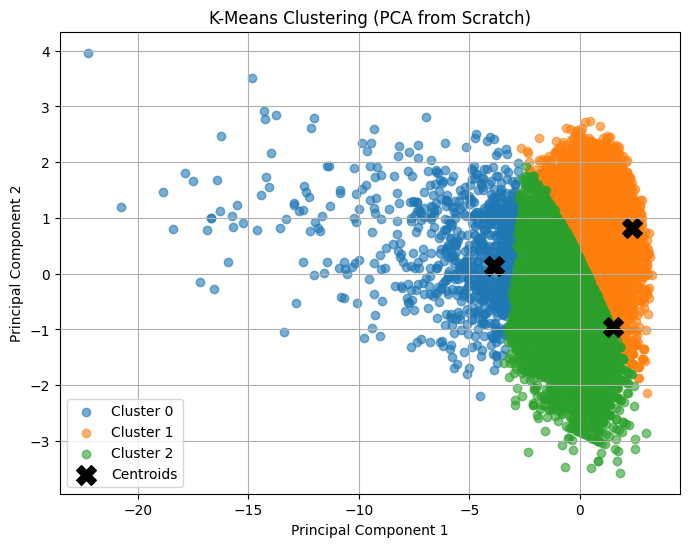

In [116]:
# Project centroids using the same PCA logic
centroids_2d = pca_from_scratch(centroids, n_components=2)

plot_clusters_2d(X_2d, clusters, centroids_2d)


## Elbow Method (from scratch)
### WCSS calculation function

In [117]:
def compute_wcss(X, clusters, centroids):
    wcss = 0.0
    for i in range(len(centroids)):
        points = X[clusters == i]
        wcss += np.sum((points - centroids[i]) ** 2)
    return wcss


In [118]:
import matplotlib.pyplot as plt

def plot_elbow_curve(X, max_k=10):
    wcss_values = []
    k_values = range(1, max_k + 1)

    for k in k_values:
        clusters, centroids = kmeans(X, k)
        wcss = compute_wcss(X, clusters, centroids)
        wcss_values.append(wcss)

    plt.figure(figsize=(8, 5))
    plt.plot(k_values, wcss_values, marker='o')
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("WCSS")
    plt.title("Elbow Method (K-Means from Scratch)")
    plt.grid(True)
    plt.show()


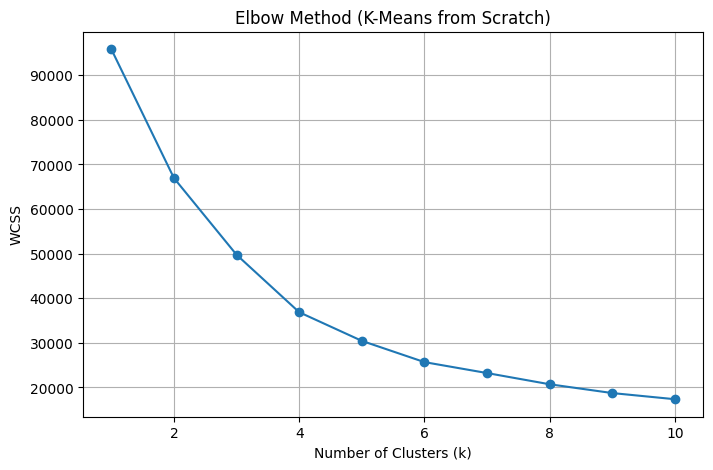

In [111]:

plot_elbow_curve(data_scaled, max_k=10)
